**Preparando los datos para el modelo**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

# Cargar y limpiar — igual que lección 2
df = pd.read_csv(
    '../datasets/household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H:%M:%S')
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)
df.dropna(inplace=True)

cols = ['Global_active_power', 'Global_reactive_power',
        'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

print(df.shape)

(2049280, 7)


Ahora construyes las features. Aquí es donde el heatmap de la Lección 2 te sirve directamente:

In [51]:
# Feature engineering — construir las variables de entrada
df['hora']        = df.index.hour
df['dia_semana']  = df.index.dayofweek
df['mes']         = df.index.month

# Features elegidas basadas en el heatmap de correlación
features = ['Global_intensity', 'Sub_metering_3',
            'Sub_metering_1', 'Sub_metering_2',
            'hora', 'dia_semana', 'mes']

X = df[features]
y = df['Global_active_power']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(X.head())

Features shape: (2049280, 7)
Target shape:   (2049280,)
                     Global_intensity  Sub_metering_3  Sub_metering_1  \
Datetime                                                                
2006-12-16 17:24:00              18.4            17.0             0.0   
2006-12-16 17:25:00              23.0            16.0             0.0   
2006-12-16 17:26:00              23.0            17.0             0.0   
2006-12-16 17:27:00              23.0            17.0             0.0   
2006-12-16 17:28:00              15.8            17.0             0.0   

                     Sub_metering_2  hora  dia_semana  mes  
Datetime                                                    
2006-12-16 17:24:00             1.0    17           5   12  
2006-12-16 17:25:00             1.0    17           5   12  
2006-12-16 17:26:00             2.0    17           5   12  
2006-12-16 17:27:00             1.0    17           5   12  
2006-12-16 17:28:00             1.0    17           5   12  


**Train/Test split y escalado**

In [52]:
# Dividir en entrenamiento y prueba — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1639424 filas
Test:  409856 filas


El random_state=42 es una semilla que fija el resultado. Sin ella, cada vez que corras el código el split sería diferente y no podrías comparar resultados entre sesiones. Anótalo en tu cuaderno.

In [53]:
# Escalado — normalizar las features al mismo rango
# La regresión lineal es sensible a las escalas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Hay una regla crítica aquí que debes anotar en tu cuaderno: el scaler se entrena solo con X_train, nunca con X_test. Si escalas con todos los datos juntos, estás dejando que el modelo "vea" el futuro durante el entrenamiento. Eso se llama data leakage y es uno de los errores más graves en ML.

**Entrenar el modelo**

In [54]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Ver los coeficientes aprendidos
coeficientes = pd.DataFrame({
    'Feature':     features,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(coeficientes)
print(f"\nIntercepto: {modelo.intercept_:.4f}")

            Feature  Coeficiente
0  Global_intensity     1.042781
1    Sub_metering_3     0.021391
4              hora     0.001292
2    Sub_metering_1    -0.000694
5        dia_semana    -0.000745
6               mes    -0.001112
3    Sub_metering_2    -0.001824

Intercepto: 1.0917


Los coeficientes son lo que el modelo aprendió. Un coeficiente alto positivo significa que cuando esa variable sube, el consumo predicho sube. Un coeficiente negativo significa lo contrario. Compara los coeficientes con lo que el heatmap te mostró: ¿coinciden con las correlaciones que viste?

**Evaluar el modelo**

In [55]:
# Predecir sobre datos que el modelo nunca vio
y_pred = modelo.predict(X_test_scaled)

# Métricas de evaluación
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f} kW")
print(f"MAE:  {mae:.4f} kW")
print(f"R²:   {r2:.4f}")

RMSE: 0.0464 kW
MAE:  0.0312 kW
R²:   0.9981


Anota en tu cuaderno qué mide cada métrica:

MAE (Mean Absolute Error): el error promedio de tus predicciones en las mismas unidades del target. Si el MAE es 0.3, el modelo se equivoca en promedio 0.3 kW.

RMSE (Root Mean Squared Error): similar al MAE pero penaliza más los errores grandes. Siempre es mayor o igual al MAE.

R² (R cuadrado): qué porcentaje de la variación del target explica tu modelo. Un R² de 0.85 significa que el modelo explica el 85% de la variación del consumo. Más cercano a 1 es mejor.

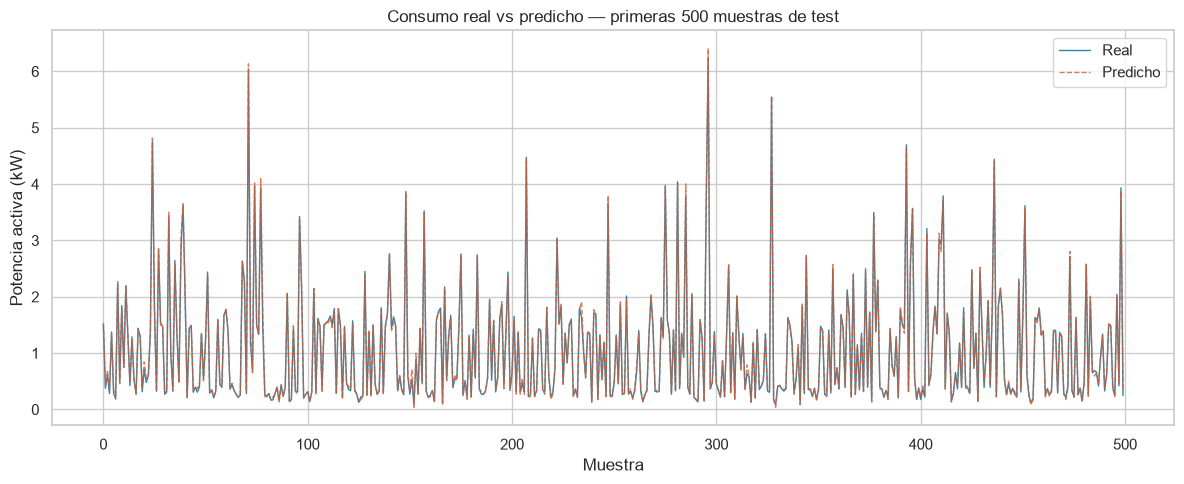

In [56]:
# Visualizar predicciones vs valores reales
muestra = 500
fig, ax = plt.subplots()
ax.plot(y_test.values[:muestra], label='Real',     color='#2E86AB', linewidth=1)
ax.plot(y_pred[:muestra],        label='Predicho', color='#D85A30',
        linewidth=1, alpha=0.8, linestyle='--')
ax.set_title('Consumo real vs predicho — primeras 500 muestras de test')
ax.set_xlabel('Muestra')
ax.set_ylabel('Potencia activa (kW)')
ax.legend()
plt.tight_layout()
plt.show()

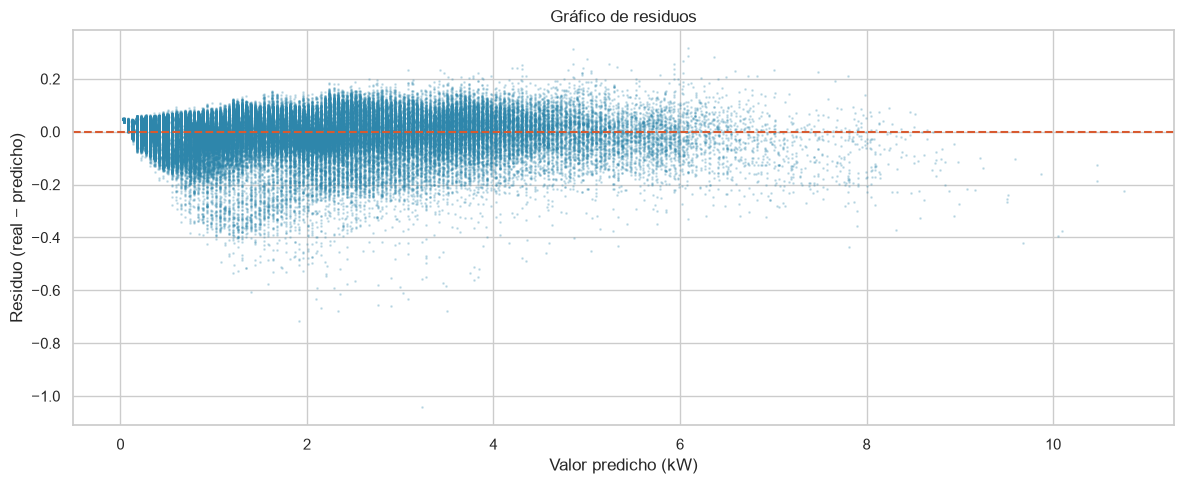

In [57]:
# Gráfico de residuos — diferencia entre real y predicho
residuos = y_test.values - y_pred

fig, ax = plt.subplots()
ax.scatter(y_pred, residuos, alpha=0.2, color='#2E86AB', s=1)
ax.axhline(y=0, color='#D85A30', linewidth=1.5, linestyle='--')
ax.set_title('Gráfico de residuos')
ax.set_xlabel('Valor predicho (kW)')
ax.set_ylabel('Residuo (real − predicho)')
plt.tight_layout()
plt.show()

El gráfico de residuos es clave: si los puntos están distribuidos aleatoriamente alrededor de la línea cero, el modelo es bueno. Si ves un patrón (una curva, un embudo), el modelo tiene un problema estructural y necesitas uno más complejo.

Se puede observar que el gráfico de residuo tiene una forma no aleatoria, por el contrario, tiene una forma pegada al cero, lo que da un indicio de un problema estructural. Asimismo, los valores de R2 tiene un valor muy alto, lo que tiende a pensar que hay un problema a nivel de features. 

Luego de ver el siguiente diagrama:

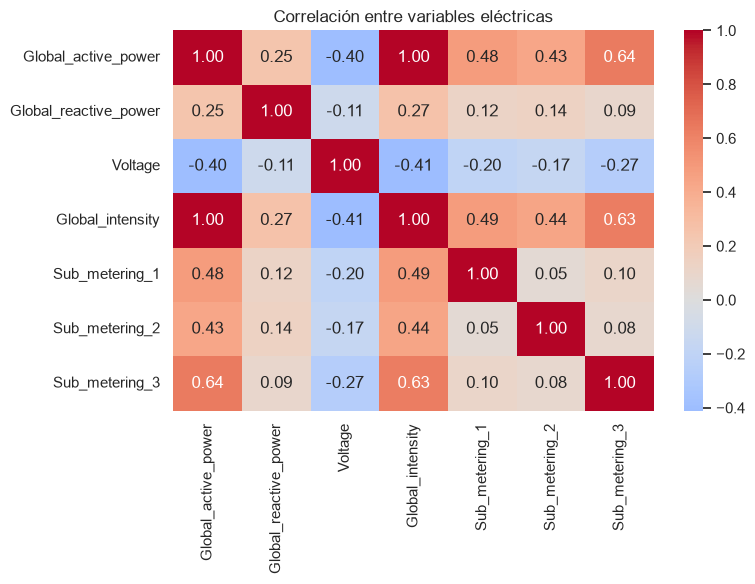

Se puede ver que Global inténsity tiene correlación perfecta de 1 con la variable de salida, lo que ocasianó que el modelo encontrara la correlación lineal entre ambos parámetros y tomara el camino corto prediciendo el valor de salida obtenido de su variable de entrada. A continuación, se hará un entrenamiento de un modelo pero eliminando la variable linealmente dependiente.

**eliminamos el feature que tenía correlación lineal perfecta**

In [58]:
# Feature engineering — construir las variables de entrada
df['hora']        = df.index.hour
df['dia_semana']  = df.index.dayofweek
df['mes']         = df.index.month

# Features elegidas basadas en el heatmap de correlación
features = ['Sub_metering_3',
            'Sub_metering_1', 'Sub_metering_2',
            'hora', 'dia_semana', 'mes']

X = df[features]
y = df['Global_active_power']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(X.head())

Features shape: (2049280, 6)
Target shape:   (2049280,)
                     Sub_metering_3  Sub_metering_1  Sub_metering_2  hora  \
Datetime                                                                    
2006-12-16 17:24:00            17.0             0.0             1.0    17   
2006-12-16 17:25:00            16.0             0.0             1.0    17   
2006-12-16 17:26:00            17.0             0.0             2.0    17   
2006-12-16 17:27:00            17.0             0.0             1.0    17   
2006-12-16 17:28:00            17.0             0.0             1.0    17   

                     dia_semana  mes  
Datetime                              
2006-12-16 17:24:00           5   12  
2006-12-16 17:25:00           5   12  
2006-12-16 17:26:00           5   12  
2006-12-16 17:27:00           5   12  
2006-12-16 17:28:00           5   12  


In [59]:
# Dividir en entrenamiento y prueba — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1639424 filas
Test:  409856 filas


In [60]:
# Escalado — normalizar las features al mismo rango
# La regresión lineal es sensible a las escalas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

**Entrenamos el modelo**

In [61]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Ver los coeficientes aprendidos
coeficientes = pd.DataFrame({
    'Feature':     features,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(coeficientes)
print(f"\nIntercepto: {modelo.intercept_:.4f}")

          Feature  Coeficiente
0  Sub_metering_3     0.584192
1  Sub_metering_1     0.413208
2  Sub_metering_2     0.374067
3            hora     0.153268
4      dia_semana     0.028179
5             mes    -0.009715

Intercepto: 1.0917


**Evaluamos nuevamente el modelo**

In [62]:
# Predecir sobre datos que el modelo nunca vio
y_pred = modelo.predict(X_test_scaled)

# Métricas de evaluación
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f} kW")
print(f"MAE:  {mae:.4f} kW")
print(f"R²:   {r2:.4f}")

RMSE: 0.5379 kW
MAE:  0.3557 kW
R²:   0.7426


**Gráfico de predicción - residuo**

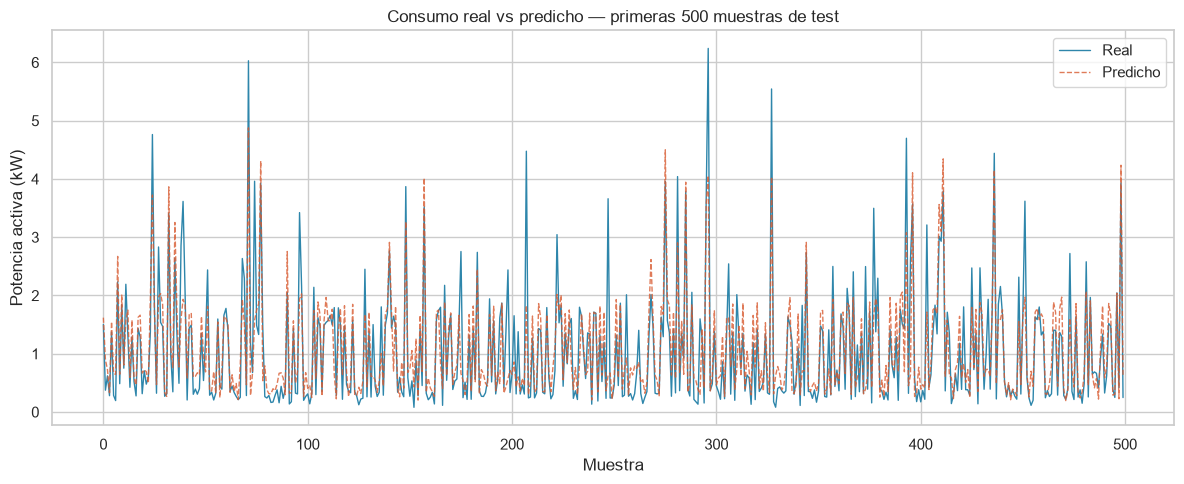

In [63]:
# Visualizar predicciones vs valores reales
muestra = 500
fig, ax = plt.subplots()
ax.plot(y_test.values[:muestra], label='Real',     color='#2E86AB', linewidth=1)
ax.plot(y_pred[:muestra],        label='Predicho', color='#D85A30',
        linewidth=1, alpha=0.8, linestyle='--')
ax.set_title('Consumo real vs predicho — primeras 500 muestras de test')
ax.set_xlabel('Muestra')
ax.set_ylabel('Potencia activa (kW)')
ax.legend()
plt.tight_layout()
plt.show()

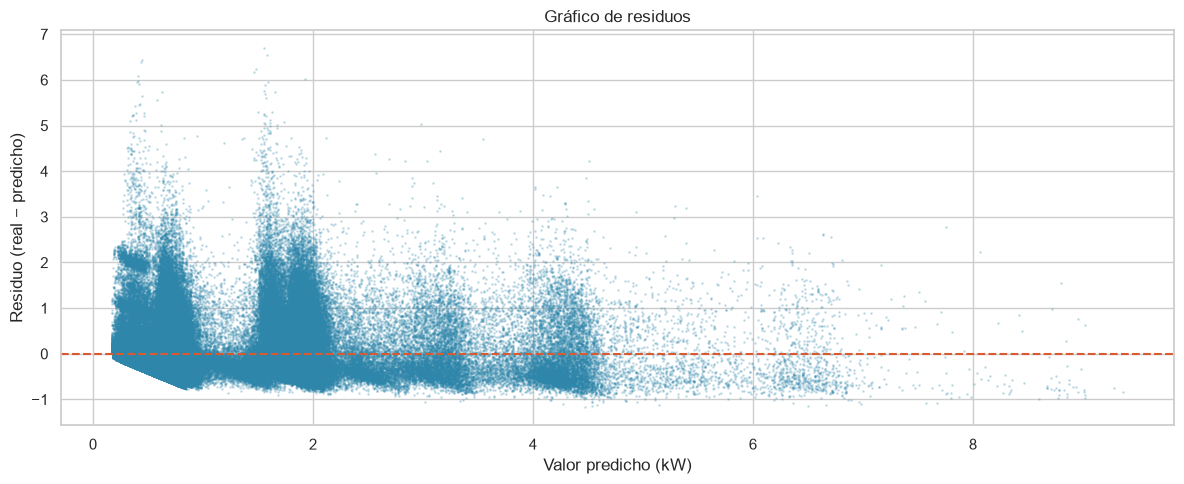

In [64]:
# Gráfico de residuos — diferencia entre real y predicho
residuos = y_test.values - y_pred

fig, ax = plt.subplots()
ax.scatter(y_pred, residuos, alpha=0.2, color='#2E86AB', s=1)
ax.axhline(y=0, color='#D85A30', linewidth=1.5, linestyle='--')
ax.set_title('Gráfico de residuos')
ax.set_xlabel('Valor predicho (kW)')
ax.set_ylabel('Residuo (real − predicho)')
plt.tight_layout()
plt.show()

Se tiene una mejor dispersión, ya no está agrupado al cero, sin embargo, se pueden observar la presencia de pico o agrupaciones de datos, y estas agrupaciones son periódicas, lo que da indicios de errores persistentes. Es necesario continuar la evaluación del modelo.

El comportamiento de los features son los siguientes:

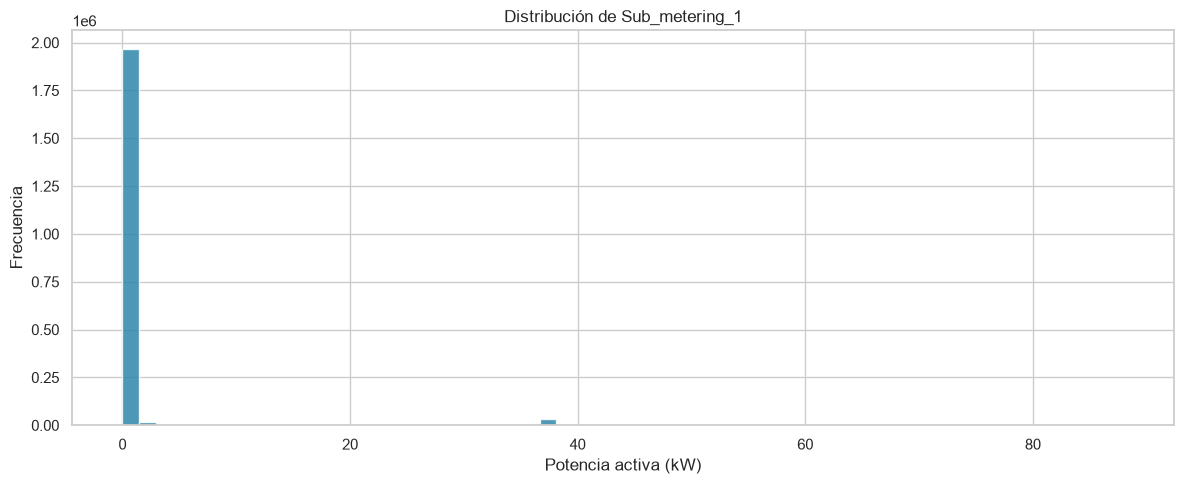
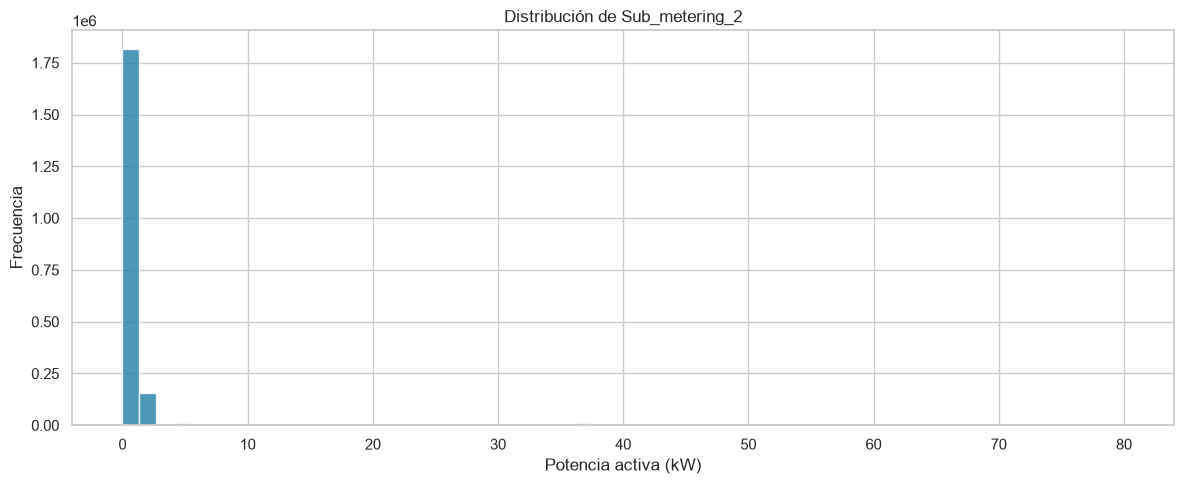
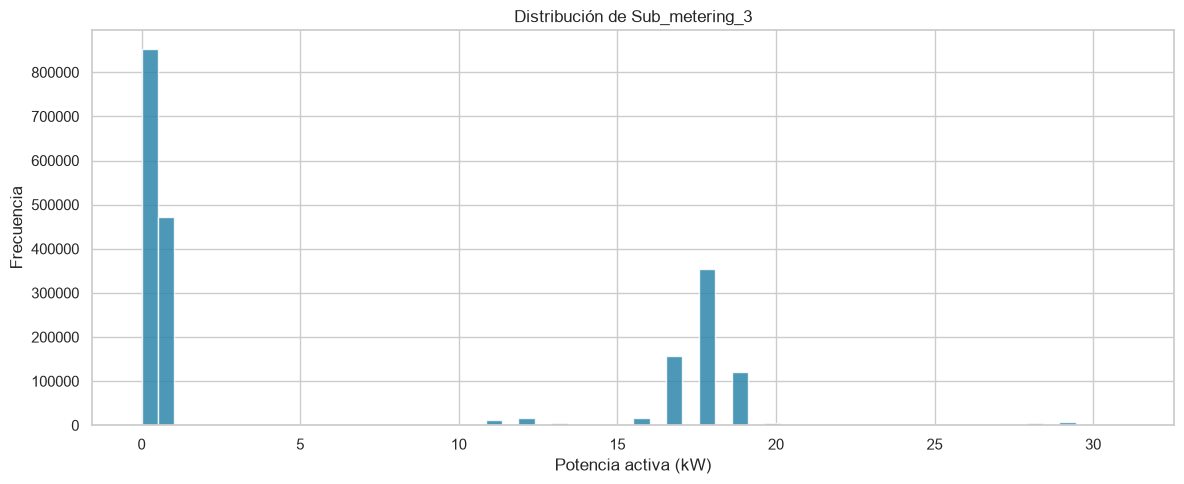
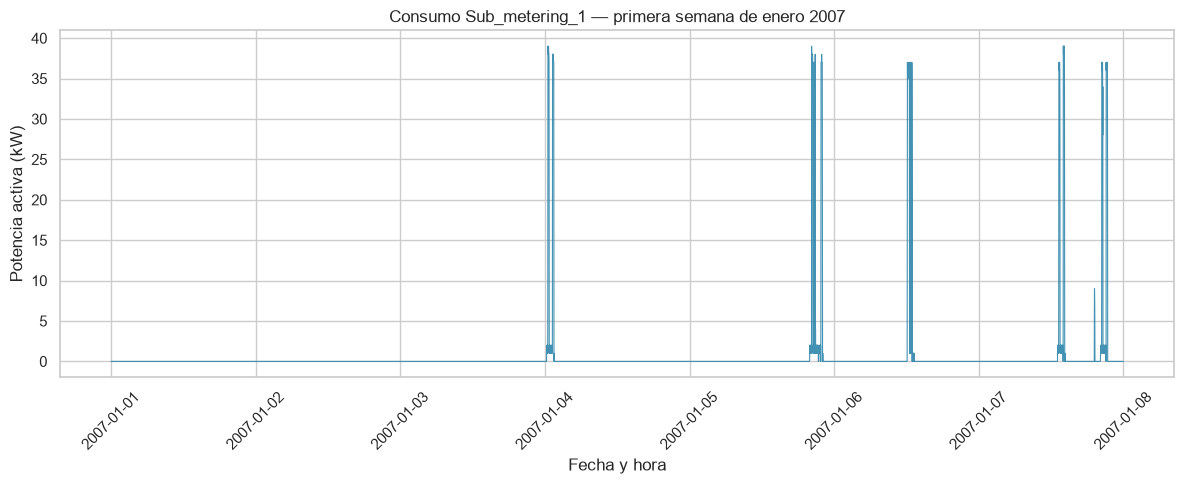
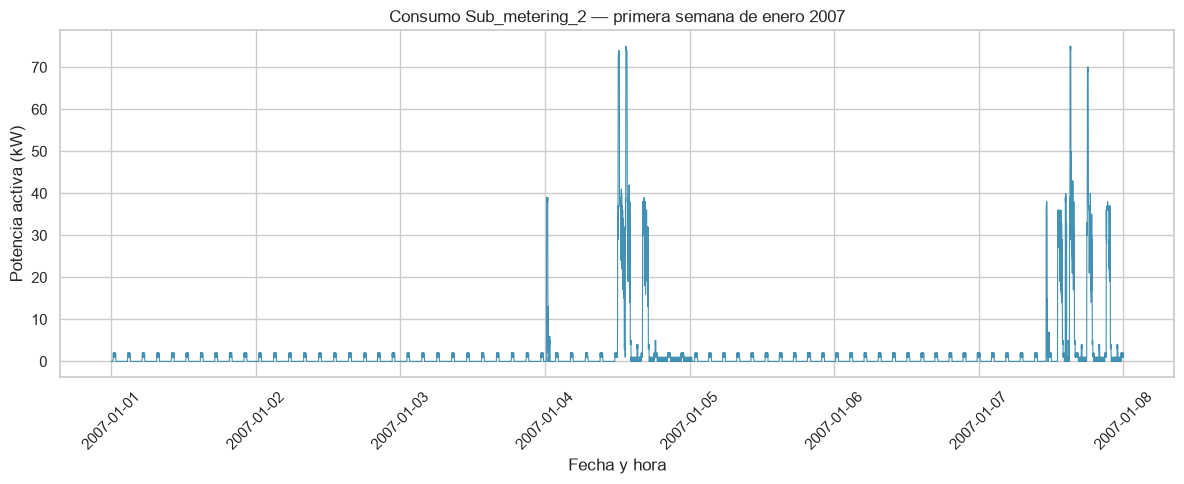
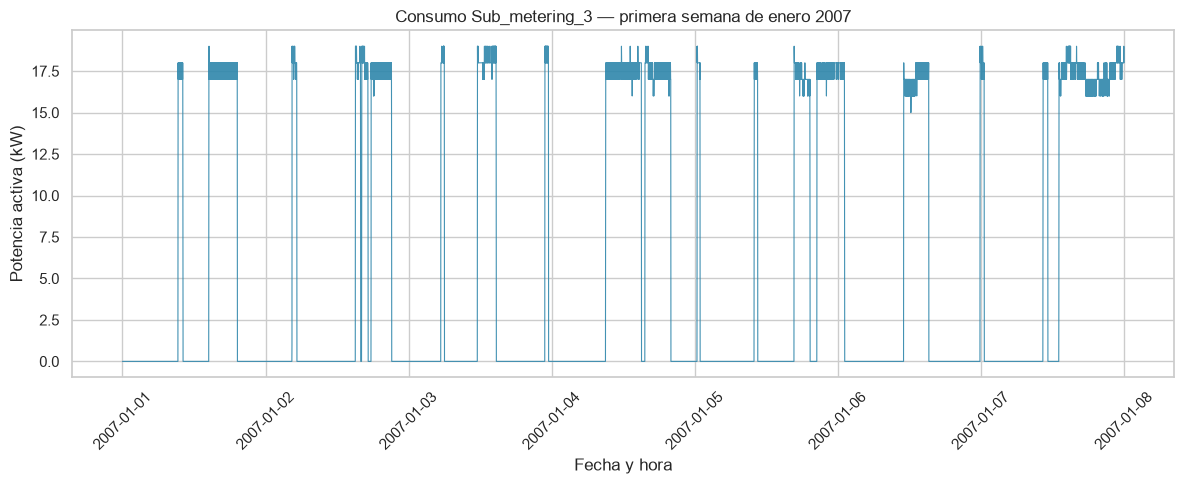

El modelo tiene buena información para predecir cuando los submedidores están en sus estados conocidos: apagado en cero, o en sus valores típicos de operación como 17 o 18 Wh. Pero para los valores intermedios del consumo global, que dependen de combinaciones de electrodomésticos que los submedidores no capturan completamente, el modelo no tiene suficiente señal y el error se dispersa. Por eso las agrupaciones en el gráfico de residuos se alinean con esos estados discretos.

Eso tiene un nombre técnico: cobertura incompleta de features. Los submedidores solo miden tres zonas de la casa, pero el consumo global incluye todo lo que no está medido: lámparas, computadoras, cargadores, televisores. Esa energía "no explicada" es exactamente el error que ves agrupado.

Esto te lleva directamente a la conclusión más importante de la lección:

La regresión lineal con estas features tiene un techo. No porque el algoritmo sea malo, sino porque los datos disponibles no describen completamente el fenómeno. Un R² de 0.74 con features limpias es honesto y real.

**Tus ejercicios independientes**

Ejercicio A: Entrena el mismo modelo pero usando solo las tres features con mayor correlación del heatmap. Compara el R² con el modelo completo. ¿Mejora, empeora o es similar? ¿Qué concluyes?

In [65]:
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

# Cargar y limpiar — igual que lección 2
df2 = pd.read_csv(
    '../datasets/household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)

df2['Datetime'] = pd.to_datetime(df2['Date'] + ' ' + df2['Time'],
                                format='%d/%m/%Y %H:%M:%S')
df2.set_index('Datetime', inplace=True)
df2.drop(columns=['Date', 'Time'], inplace=True)
df2.dropna(inplace=True)

cols = ['Global_active_power', 'Global_reactive_power',
        'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df2[cols] = df2[cols].apply(pd.to_numeric, errors='coerce')
df2.dropna(inplace=True)

print(df2.shape)

(2049280, 7)


In [ ]:
# Features elegidas basadas en el heatmap de correlación
features = ['Sub_metering_3',
            'Sub_metering_1', 'Voltage',
            'hora', 'dia_semana', 'mes']

X = df2[features]
y = df2['Global_active_power']

print(f"Features shape: {X.shape}") 
print(f"Target shape:   {y.shape}")
print(X.head())

Features shape: (2049280, 6)
Target shape:   (2049280,)
                     Sub_metering_3  Sub_metering_1  Voltage  hora  \
Datetime                                                             
2006-12-16 17:24:00            17.0             0.0   234.84    17   
2006-12-16 17:25:00            16.0             0.0   233.63    17   
2006-12-16 17:26:00            17.0             0.0   233.29    17   
2006-12-16 17:27:00            17.0             0.0   233.74    17   
2006-12-16 17:28:00            17.0             0.0   235.68    17   

                     dia_semana  mes  
Datetime                              
2006-12-16 17:24:00           5   12  
2006-12-16 17:25:00           5   12  
2006-12-16 17:26:00           5   12  
2006-12-16 17:27:00           5   12  
2006-12-16 17:28:00           5   12  


In [81]:
# Dividir en entrenamiento y prueba — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1639424 filas
Test:  409856 filas


In [68]:
# Escalado — normalizar las features al mismo rango
# La regresión lineal es sensible a las escalas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [69]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Ver los coeficientes aprendidos
coeficientes = pd.DataFrame({
    'Feature':     features,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(coeficientes)
print(f"\nIntercepto: {modelo.intercept_:.4f}")

          Feature  Coeficiente
0  Sub_metering_3     0.571270
1  Sub_metering_1     0.401497
3            hora     0.160066
4      dia_semana     0.037688
5             mes    -0.016353
2         Voltage    -0.161867

Intercepto: 1.0917


In [70]:
# Predecir sobre datos que el modelo nunca vio
y_pred = modelo.predict(X_test_scaled)

# Métricas de evaluación
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f} kW")
print(f"MAE:  {mae:.4f} kW")
print(f"R²:   {r2:.4f}")

RMSE: 0.6390 kW
MAE:  0.4247 kW
R²:   0.6368


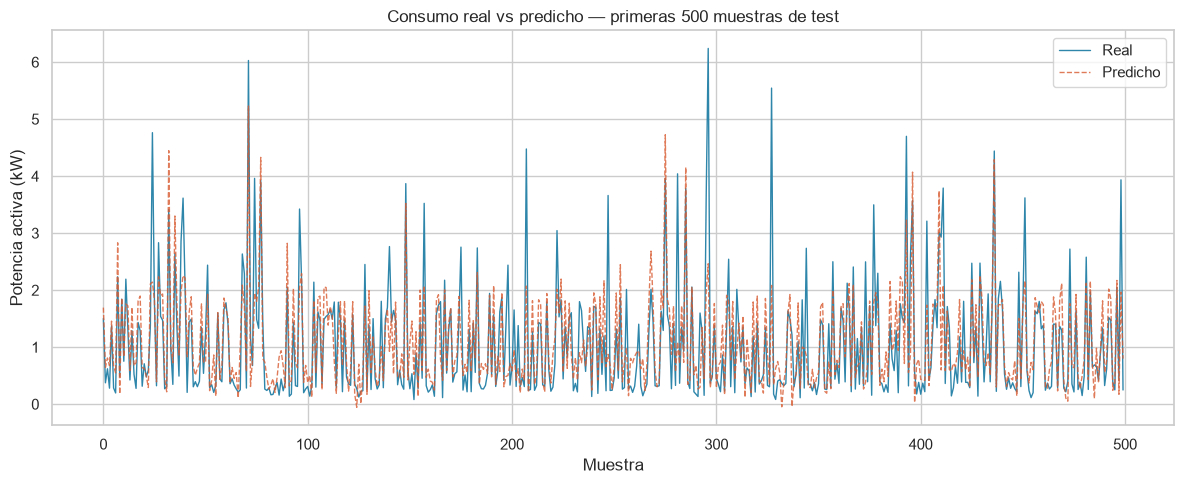

In [71]:
# Visualizar predicciones vs valores reales
muestra = 500
fig, ax = plt.subplots()
ax.plot(y_test.values[:muestra], label='Real',     color='#2E86AB', linewidth=1)
ax.plot(y_pred[:muestra],        label='Predicho', color='#D85A30',
        linewidth=1, alpha=0.8, linestyle='--')
ax.set_title('Consumo real vs predicho — primeras 500 muestras de test')
ax.set_xlabel('Muestra')
ax.set_ylabel('Potencia activa (kW)')
ax.legend()
plt.tight_layout()
plt.show()

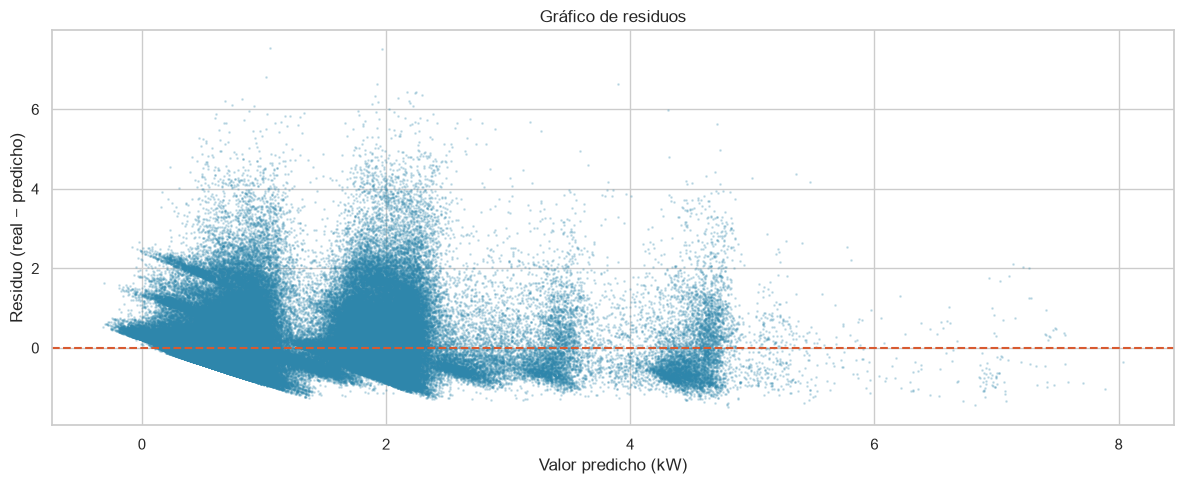

In [72]:
# Gráfico de residuos — diferencia entre real y predicho
residuos = y_test.values - y_pred

fig, ax = plt.subplots()
ax.scatter(y_pred, residuos, alpha=0.2, color='#2E86AB', s=1)
ax.axhline(y=0, color='#D85A30', linewidth=1.5, linestyle='--')
ax.set_title('Gráfico de residuos')
ax.set_xlabel('Valor predicho (kW)')
ax.set_ylabel('Residuo (real − predicho)')
plt.tight_layout()
plt.show()

Según lo mostrado el valor del R2 y demás métricas mostraron que el modelo disminuyó en su capacidad de predicción, pasando de un valor de 0.74 en R2 a 0.63. Esto puede deberse a que el valor de voltaje no explica como tal el comportamiento del consumo eléctrico, esto porque el valor de voltage se mantiene constante dentro de los parámetros de consumo habitual pues la empresa que entrega la energía se encarga de que el mismo se mantenga estable. 

Ejercicio B: Cambia test_size=0.2 por test_size=0.3 y vuelve a entrenar. ¿Cómo cambian las métricas? 

In [73]:
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

# Cargar y limpiar — igual que lección 2
df3 = pd.read_csv(
    '../datasets/household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)

df3['Datetime'] = pd.to_datetime(df3['Date'] + ' ' + df3['Time'],
                                format='%d/%m/%Y %H:%M:%S')
df3.set_index('Datetime', inplace=True)
df3.drop(columns=['Date', 'Time'], inplace=True)
df3.dropna(inplace=True)

cols = ['Global_active_power', 'Global_reactive_power',
        'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df3[cols] = df3[cols].apply(pd.to_numeric, errors='coerce')
df3.dropna(inplace=True)

print(df3.shape)

(2049280, 7)


In [74]:
# Feature engineering — construir las variables de entrada
df3['hora']        = df3.index.hour
df3['dia_semana']  = df3.index.dayofweek
df3['mes']         = df3.index.month

# Features elegidas basadas en el heatmap de correlación
features = ['Sub_metering_3',
            'Sub_metering_1', 'Voltage',
            'hora', 'dia_semana', 'mes']

X = df3[features]
y = df3['Global_active_power']

print(f"Features shape: {X.shape}") 
print(f"Target shape:   {y.shape}")
print(X.head())

Features shape: (2049280, 6)
Target shape:   (2049280,)
                     Sub_metering_3  Sub_metering_1  Voltage  hora  \
Datetime                                                             
2006-12-16 17:24:00            17.0             0.0   234.84    17   
2006-12-16 17:25:00            16.0             0.0   233.63    17   
2006-12-16 17:26:00            17.0             0.0   233.29    17   
2006-12-16 17:27:00            17.0             0.0   233.74    17   
2006-12-16 17:28:00            17.0             0.0   235.68    17   

                     dia_semana  mes  
Datetime                              
2006-12-16 17:24:00           5   12  
2006-12-16 17:25:00           5   12  
2006-12-16 17:26:00           5   12  
2006-12-16 17:27:00           5   12  
2006-12-16 17:28:00           5   12  


In [75]:
# Dividir en entrenamiento y prueba — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1434496 filas
Test:  614784 filas


In [76]:
# Escalado — normalizar las features al mismo rango
# La regresión lineal es sensible a las escalas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [77]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Ver los coeficientes aprendidos
coeficientes = pd.DataFrame({
    'Feature':     features,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(coeficientes)
print(f"\nIntercepto: {modelo.intercept_:.4f}")

          Feature  Coeficiente
0  Sub_metering_3     0.571272
1  Sub_metering_1     0.401718
3            hora     0.159970
4      dia_semana     0.037699
5             mes    -0.016649
2         Voltage    -0.161994

Intercepto: 1.0919


In [78]:
# Predecir sobre datos que el modelo nunca vio
y_pred = modelo.predict(X_test_scaled)

# Métricas de evaluación
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f} kW")
print(f"MAE:  {mae:.4f} kW")
print(f"R²:   {r2:.4f}")

RMSE: 0.6390 kW
MAE:  0.4246 kW
R²:   0.6356


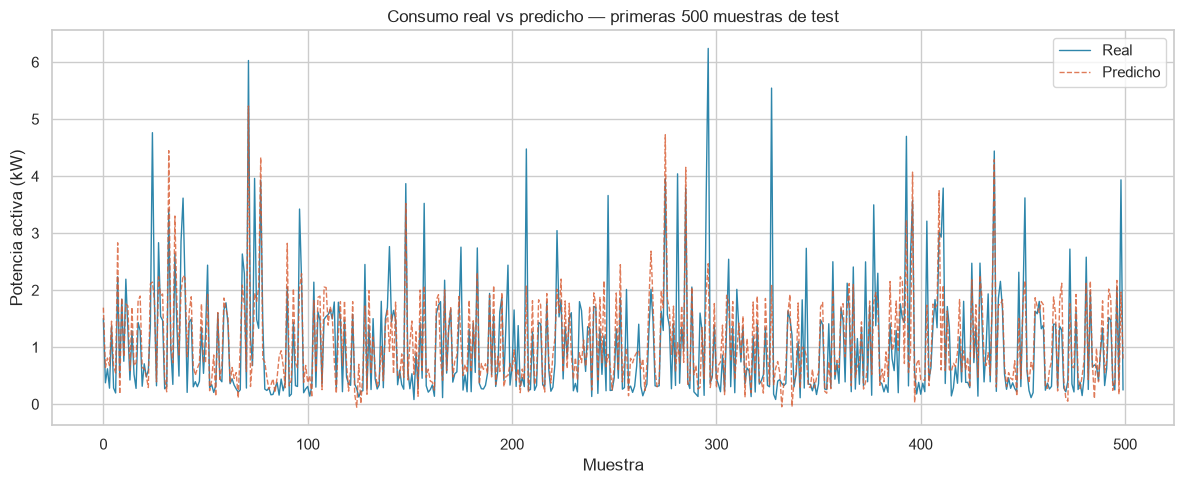

In [79]:
# Visualizar predicciones vs valores reales
muestra = 500
fig, ax = plt.subplots()
ax.plot(y_test.values[:muestra], label='Real',     color='#2E86AB', linewidth=1)
ax.plot(y_pred[:muestra],        label='Predicho', color='#D85A30',
        linewidth=1, alpha=0.8, linestyle='--')
ax.set_title('Consumo real vs predicho — primeras 500 muestras de test')
ax.set_xlabel('Muestra')
ax.set_ylabel('Potencia activa (kW)')
ax.legend()
plt.tight_layout()
plt.show()

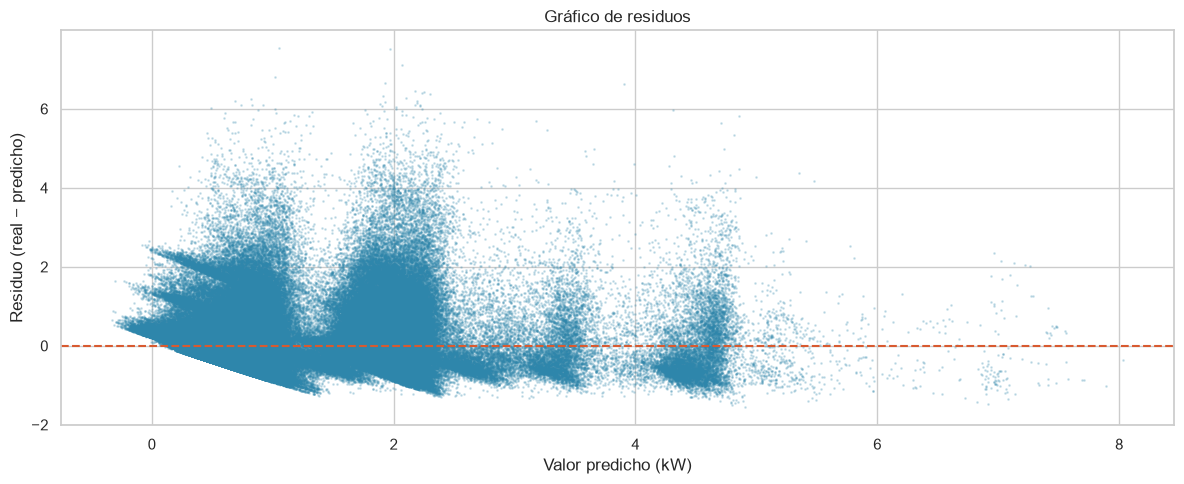

In [80]:
# Gráfico de residuos — diferencia entre real y predicho
residuos = y_test.values - y_pred

fig, ax = plt.subplots()
ax.scatter(y_pred, residuos, alpha=0.2, color='#2E86AB', s=1)
ax.axhline(y=0, color='#D85A30', linewidth=1.5, linestyle='--')
ax.set_title('Gráfico de residuos')
ax.set_xlabel('Valor predicho (kW)')
ax.set_ylabel('Residuo (real − predicho)')
plt.tight_layout()
plt.show()

El valor de las metricas se mantienen constantes a pesar de haber variado el porcentaje de contenido de los grupos de train y test. El motivo es que el la cantidad de datos no afecta la cantidad de aprendizaje del modelo, es decir, el modelo es robusto frente a una reducción mínima de datos.